In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [2]:
orders_shipped = pd.read_csv("data/order_shipped_dates.csv", parse_dates=['event_timestamp'])

In [3]:
orders_shipped.head()

,ed_id,event_timestamp
0,28,2021-06-23 00:00:00+00:00
1,28,2021-04-08 00:00:00+00:00
2,28,2021-08-18 00:00:00+00:00
3,28,2021-04-05 00:00:00+00:00
4,28,2022-06-07 00:00:00+00:00


In [47]:
daily_orders = (
    orders_shipped
        .set_index('event_timestamp')
        .resample('D')
        .size()
)

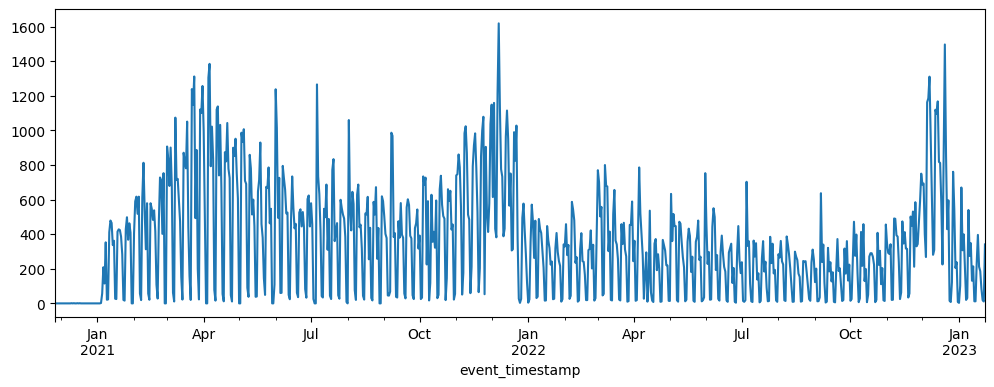

In [18]:
daily_orders.plot(figsize=(12, 4))
plt.show()

In [ ]:
# Top 10 days with most orders shipped, clear holiday for Christmas/winter holiday peak
daily_orders.sort_values(ascending=False)[:10]

event_timestamp
2021-12-07 00:00:00+00:00    1619
2022-12-20 00:00:00+00:00    1497
2021-04-06 00:00:00+00:00    1385
2021-03-24 00:00:00+00:00    1312
2022-12-07 00:00:00+00:00    1311
2021-04-05 00:00:00+00:00    1305
2021-07-06 00:00:00+00:00    1266
2021-03-31 00:00:00+00:00    1257
2021-03-22 00:00:00+00:00    1239
2021-06-01 00:00:00+00:00    1238
dtype: int64

In [15]:
bimonthly_orders = (
    orders_shipped
        .set_index('event_timestamp')
        .resample('SMS')
        .size()
)

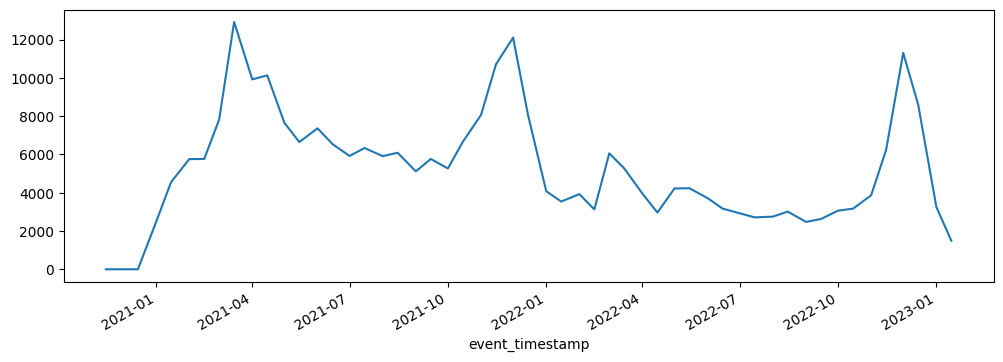

In [16]:
bimonthly_orders.plot(figsize=(12, 4))
plt.show()

In [4]:
monthly_orders = (
    orders_shipped
        .set_index('event_timestamp')
        .resample('MS')
        .size()
)

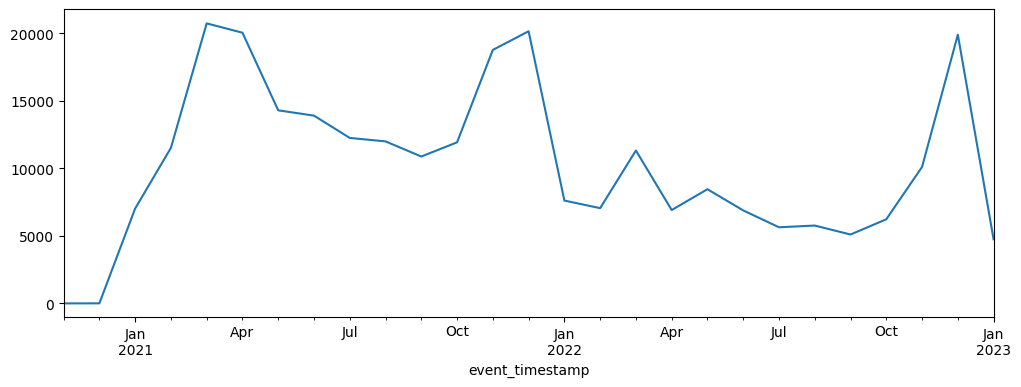

In [5]:
monthly_orders.plot(figsize=(12, 4))
plt.show()

Our actual model will be fit to either monthly or bi-monthly data, which we will ultimately use to project the ordered quantity for each month.

### Monthly Data Model

In [63]:
df_monthly = monthly_orders.reset_index().rename(columns={'event_timestamp': 'ds', 0: 'y'})
df_monthly = df_monthly.loc[df_monthly['ds'] >= '2021-01-01'].reset_index(drop=True)
df_monthly['ds'] = df_monthly['ds'].dt.date

# Add upper and lower limits
df_monthly['cap'] = int(1.1 * df_monthly['y'].max())
df_monthly['floor'] = 4000

holidays = pd.DataFrame({
    'holiday': 'winter_holiday',
    'ds': pd.to_datetime(['2021-12-01', '2022-12-01', '2023-12-01', '2024-12-01'])
})

In [64]:
model = Prophet(growth='logistic', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, holidays=holidays)
model.add_seasonality(
    name='annual',
    period=365.25,
    fourier_order=3,
    prior_scale=1.0
)
model.fit(df_monthly)

future_dates = model.make_future_dataframe(periods=24, freq='MS')
future_dates['cap'] = df_monthly.loc[0, 'cap']
future_dates['floor'] = df_monthly.loc[0, 'floor']
forecast_df = model.predict(future_dates)

12:05:45 - cmdstanpy - INFO - Chain [1] start processing
12:05:45 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
forecast_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
44,2024-09-01,1805.083369,-852.828284,4450.566497
45,2024-10-01,5526.280157,3086.237367,8178.995323
46,2024-11-01,9056.301781,6489.351134,11771.135080
47,2024-12-01,15695.044880,13019.594855,18267.072807
48,2025-01-01,-91.389144,-2713.546113,2682.445273


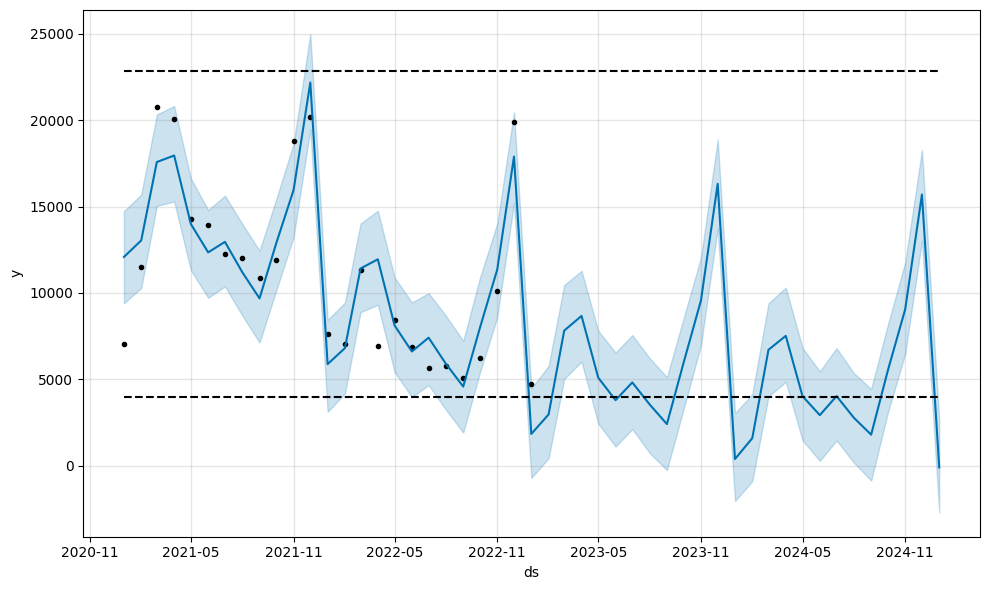

In [66]:
model.plot(forecast_df)
plt.show()

In [67]:
print(f"Number of negative month predictions: {forecast_df[forecast_df['yhat'] < 0].shape[0]}")

Number of negative month predictions: 1


In [69]:
forecast_df.loc[forecast_df['yhat'] < 0, 'yhat']

48   -91.389144
Name: yhat, dtype: float64

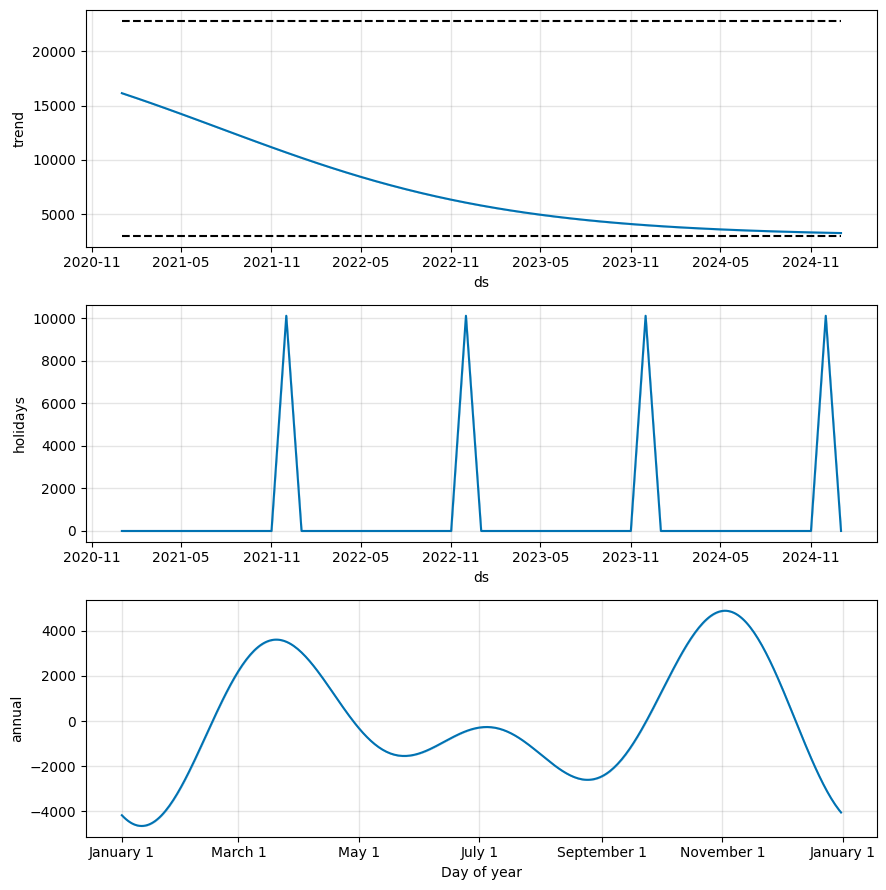

In [53]:
model.plot_components(forecast_df)
plt.show()